## B Trees and B+ Trees

- We have seen how AVL trees work to keep BSTs balanced to maintain logarithmic time search, insertion, and deletion performance 

- The underlying assumption here is that the entire AVL tree fits in memory, and pointers are just memory addresses. 

- However, we very often have trees that spill over to disk, because not every tree is small enough to be kept in-memory!
    - For example, we may represent some database values as a tree to enable faster lookup.

- B Trees are useful in such cases where we need to work with disk memory!

In [ ]:
import graphviz
from utils import BaseNode

### Background Lore of B-Trees / B+ Trees

- Understanding the origins for B Trees over AVL Trees or regular BSTs requires a huge detour, but I promise the payoff is EXTREMELY satisfying. If you don't care, feel free to skip this bit!

#### How do we store data on disk?

- Let's consider the example we gave above, where we'd like to represent a database as a tree so that we can make use of the logarithmic time search/insertion/deletion properties

- But databases are not small, so building and maintaining a BST of an entire base and keeping it in memory is not very scalable. Naturally, a logical way to deal with this issue is to store data on disk instead of in memory

- What does it mean when we say, "store data on disk"? Consider this screenshot from [Abdul Bari](https://www.youtube.com/watch?v=aZjYr87r1b8)

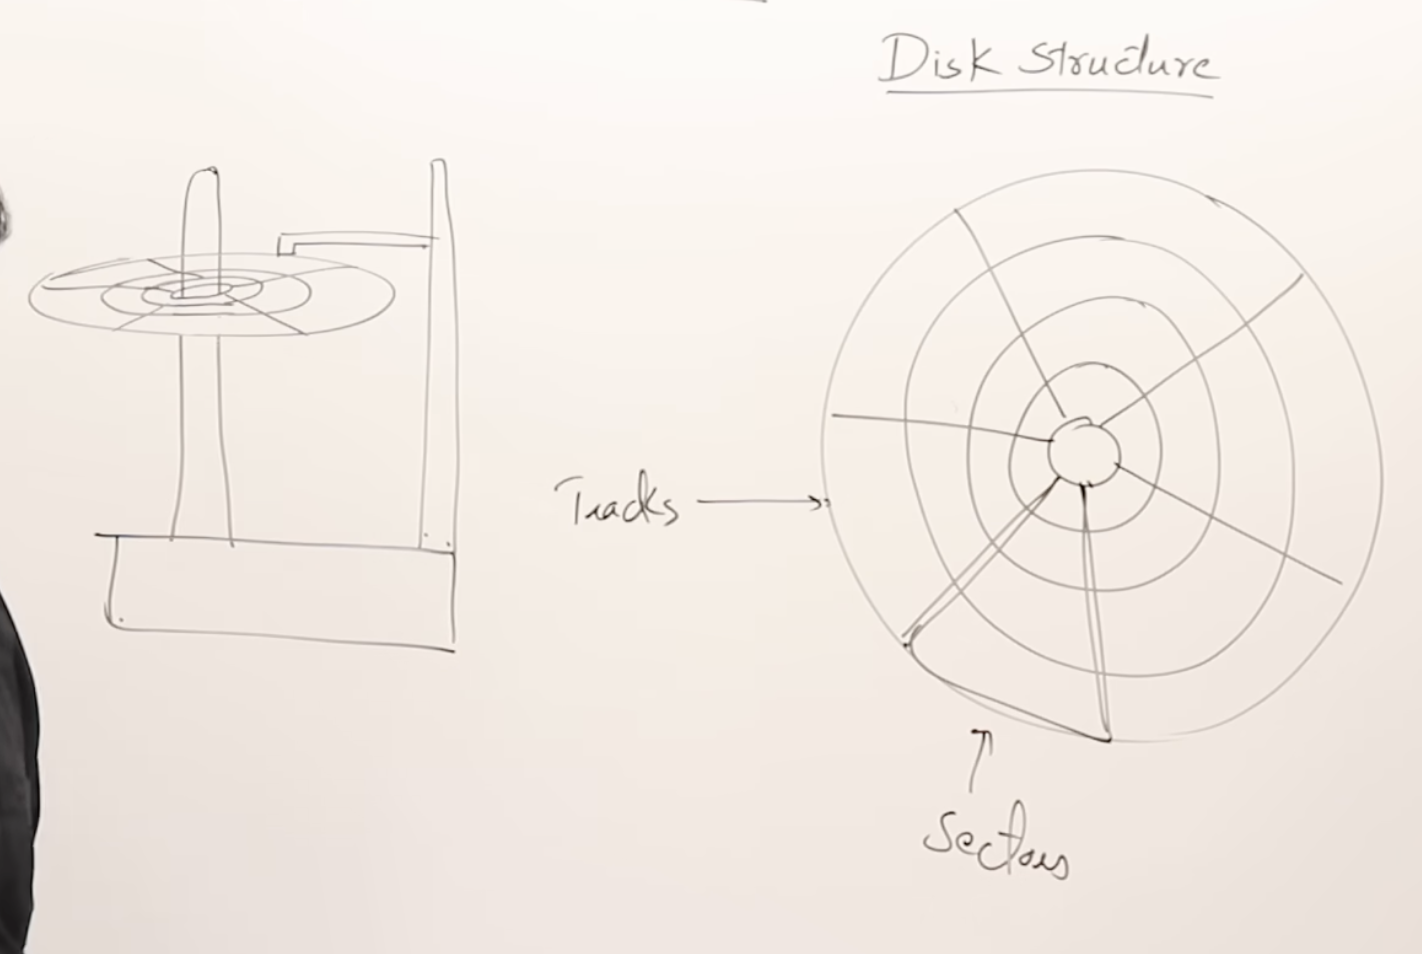

In [2]:
from IPython.display import Image, display
display(Image("Screenshot 2026-04-05 at 11.37.13 AM.png"))

- Imagine a disk as a circular bit of silicon
    - This bit can be divided into pizza slices, called **Sectors**, and also into circular regions, called **Tracks**
    - The combination of tracks and sectors identify unique segments of the disk, which are known as **Blocks**
    - The address of the block is simply the combination (track number, sector number)

- To read/write to/from a dis, we rely on a mechanical arm
    - The arm moves in 1 axis; inwards/outwards. This movement allows the arm to read from different tracks
    - To read a different sector, the disk rotates
    - This combination of arm movement and disk rotation lets us access any part of the hard disk drive

- A block can be of arbitrary size, but in this example let's assume it is 512 bytes
    - You can visualise this as a reactangle with 512 memory slots
    - The index of each memory slot is known as the **offset**

- Remember, this is data stored on disk, which is different from the data stored in memory
    - When we want to access disk data, the computer physically changes the position of the disk and arm to reach the specific byte of interest
    - This is then copied into the main memory of the computer for us to access

- This split in disk vs memory gives rise to a broad dichotomy:
    - The organisation of data inside the main memory for direct use by the program is done via **data structures**
    - The organisation of data inside the disk efficiently is done via **Database Management Systems (DBMS)**

- In our case, B-Trees will fall under this idea of DBMS

#### How does DBMS query data?

- Now that we understand how data is stored on disk, let's consider how data is stored using the following simplified database

    | id | name | dept | ... |
    | - | - | - | - |
    | 1 | John | ... | ... |
    | ... | ... | ... | ... |

- Let's suppose there are 5 columns total, and each of these columns are provisioned with the following bytes
    - `id`: 10 bytes
    - `name`: 50 bytes
    - `dept`: 10 bytes
    - `section`: 8 bytes
    - `address`: 50 bytes
    - **Total: 128 bytes per row**

- Since each block has 512 bytes as we concluded, every block can store 4 rows. If there are, say, 100 rows in our database, then we need 25 blocks

- Suppose we run `SELECT * FROM TABLE WHERE id = 1` 
    - If we insert rows into blocks randomly, we need to query 25 blocks to guarantee that we find the correct value!

- HOW CAN WE DO BETTER?

#### Indexing for faster queries

- We know that modern databases make use of something called an **index**. In any DBMS (e.g. MySQL), you will be prompted to index your database the moment it is created. What exactly is this doing?

- Suppose we want to index the table above on the column `id`. All this means is that we create **ANOTHER** table with the following schema

    | id | pointer | 
    | - | - | 
    | 1 | abc123 | 
    | 2 | bcd234 | 
    | ... | ... |

- Basically using the indexing column, we store a pointer which points to the exact memory index where the data sits! In this case, it simply stores a combination of block address and offset
    - In our case, we assumed that `id` has 10 bytes, and let's assume that the pointer needs 6 bytes
    - This gives us 16 bytes per record
    - At 512 bytes per block, that means we store 32 index entries per block
    - For a table with 100 rows, we need approximately 4 blocks to store this index information

- Now, lookups require less block access! 
    - Previously: Search 25 different blocks for the data we want 
    - Now: Search 4 blocks of the indices to find the pointer to the information we want, then search 1 block to access the data

- Therefore, indexing is a space <--> time tradeoff; we use a little more disk space to reduuce the time needed for lookups!

- Since our index table has 1 entry for every unit of data, this is known as a **dense index** 

#### Multilevel Indexing for Large Index

- We previously explored the case where we had a table with 100 records, with each record taking around 128 bytes
    - In a disk with 512 bytes per block, we found that this took 25 blocks
    - In addition, we use 4 more blocks to construct an dense index to reduce the amount of block reads we need to do when we perform queries

- You can see how this quickly becomes unmanageable. Imagine if I have 1500 records
    - Now, I need 375 blocks to store my data ($1500 * 128 \text{ bytes per data} / 512 \text{ bytes per block} = 375$)
    - And I need 47 blocks to store my index pointers ($1000 * 16 \text{ bytes per data} / 512 \text{ bytes per block} \approx 47$) 
    - This means that a basic 1500 row table will force me to look up 48 blocks, just to find the right index! 
        - If I query record 1500, I scan through all 47 blocks in the L1 index looking for record 1500 to find its pointer value from the index. 
        - Then, I read 1 more block to access what the pointer points to, for a total of 48 blocks scanned.

- However, nothing is stopping us from doing the same thing to the index table! Solution here is to **index the index**, also known as **multilevel indexing**
    - Level 1 Index (Dense): Consists of the 47 blocks containing the pointers to all 1500 records
    - Level 2 Index (Sparse): We create a "summary" table. Each row represents one of the 47 blocks from Level 1, storing the starting id of that block and its physical address on the disk. 
        - Remember, L1 index stores pointers to individual data entries. L2 index stores pointers to the start of blocks!
        - Therefore, the L2 index only requires 47 entries, which fits easily into just 2 blocks. (16bytes * 47 entries / 512bytes per block)
        - In L2 index block 1, we have pointers to the first entries of blocks 1 to 32 of the L1 index. And L2 index block 2 will have pointers to the first entries of blocks 33 - 47 of the L1 index
        
- Now, if we query record 1500
    - Scan the Level 2 Index (2 blocks)
    - Record 1500 must be in the range handled by Block 47 of the Level 1 index
        - Why? Recall that every block in the L1 index must contain only 32 entries. Therefore, we can find the correct block by taking $\text{ID} // 32 + 1$
    - The second index has 2 blocks, so we scan 2 blocks
    - This will give us the exact block of index 1 where the pointer to record 1500 is stored. So we scan that block to get the pointer to record 1500
    - Finally, we move to the exact block containing the record, and scan it.
    - This gives us a total of 4 blocks scanned

- Therefore, from the prior 48 blocks scanned, we now only scan 4!

#### Link to B Trees and B+ Trees

- The example above demonstrates how databases query data, and how indices are built and used to minimise block access 

- But let's take a closer look at this multilevel indexing we just did:
    - We have our first index with size 1000
    - We have our second index with size 40
    - We have our third index with sie 2
    - If we flip this around, with 1000 at the bottom, 40 in the middle, and 2 at the top, this suddenly starts looking SUSPICIOUSLY like a tree structure!

- **KEY POINT:** A multilevel index can be represented by a tree! We have shown how multi level indexing in databases enable fast lookup, and drawn a parallel between the multi level index structure and the tree structure

- Problem: This cannot just be a simple BST
    - For one, the branching factor is way more than 2. We went from a 2 value root, to 40 value middle layer, to a 1000 value leaf layer
    - For another, what we ideally want is a tree that is smart enough to: 
        - Expand its depth automatically when a new row is added (if needed)
        - Expand its depth automatically when a row is deleted (if needed)

- Let's now look into how we can modify a BST to meet these requirements!

### M-Way Search Trees

- Before we discuss B Trees for real, we first need to understand the general form of a BST.
- In a BST, every node holds 1 value, and 2 children

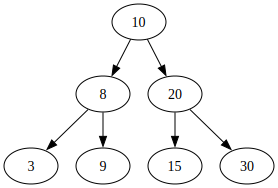

In [ ]:
dot = graphviz.Digraph()
connections = [('10', '8'),('10', '20'),('8', '3'),('8', '9'),('20', '15'),('20', '30')]
for parent, child in connections:
    dot.edge(parent, child)
dot

- Must this always be true? Of course not! 
- What is stopping us from having 2 values per node, and 3 children per node?

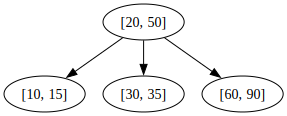

In [8]:
dot = graphviz.Digraph()
connections = [('[20, 50]', '[10, 15]'),('[20, 50]', '[30, 35]'),('[20, 50]', '[60, 90]'),]
for parent, child in connections:
    dot.edge(parent, child)
dot

- This is also a valid tree! And we get the same logarithmic time performance too
    - Suppose we are looking for the number 30
    - We start from the root node. 30 is between 20 and 50, so we traverse to the middle child
    - And we find 30

- In fact, there is no theoretical limit to this
    - If every node has $X$ keys, this gives us a branching factor of $X+1$
    - In the example above, we have 2 keys. So we have a branching factor of 3, giving us 3 way search tree
    - If we have M-1 keys, and M branches, then we have M way search tree

- What does a node of an M-way search tree look like?
    - In a 2 way search tree (or BST) we hold 3 pieces of information; one key, the left child pointer, and the right child pointer
    - In a 3 way search tree, we now have 2 keys, and 3 pointers
    - In an M way search tree, we have M-1 keys, and M pointers!

- We are now a step closer to our example in the previous section; it turns out that it is entirely possible to express the index branching of 2 --> 40 --> 1000 using a tree
    - If a node can take on a range of values rather than a single value, then each node can be seen as 1 memory block
    - In this way, every node we traverse in the tree is simply one block read
    - The more we traverse, the more blocks we read. So it is in our interest to keep the tree height as low as possible

- What would a node of an M-way search tree look like then? As an example, let's assume we are dealing with a 4 way search tree.
    - Every node must have pointers to at most 4 children
    - Every node must have 3 keys
    - Every node must have pointers to the block address of the 3 keys. Let's call these the record pointers
    - Therefore:
        - if the value you are looking for is not any of the 3 keys, we use the pointers to one of the four children to narrow our range of search
        - if the value you are looking for is one of the 3 keys, we use the record pointers to get to the block holding the main index, which contains the the memory pointer of the key

In [ ]:
from dataclasses import dataclass

@dataclass
class KeyWithPointer:
    key: int
    address: str

class MyMWayNode(BaseNode):
    def __init__(self, max_branching_factor: int, is_leaf: bool):
        self.max_branching_factor: int = max_branching_factor
        self.is_leaf: bool = is_leaf
        self.children: list[MyMWayNode] = []
        self.keys: list[KeyWithPointer] = []
    ...


### B Trees

- M-way search trees give us the structure we need for a tree with arbitary branching factor. However, it is missing an important consideration; We have not given any thought to how the tree is built

- Recall that in database indexing, we said that we can treat every node of the tree as a block range. By this logic, the more we traverse, the more blocks we read. So it is in our interest to keep the tree height as low as possible

- But M-way seearch trees do not give any explicit guidelines on how we build the tree! 
    - Suppose we build it like a BST with `[10, 20, 30]`
    - With 10, we create a new root node
    - With 20, do we append it to the root? Do we branch? 
        - If we keep appending to the root, what happens if we have `[10, 1000, 20, 30]`?? Everything will end up being to the left of the root, because the range is so large
        - If we keep branching, we end up with a linked list, and lose our tree structure

- Therefore, we need some logic to keep the tree balanced and enable it to build/prune itself automatically. We will discuss this logic for search, insertion, and deletion.
    - Note that this is not the only possible insertion logic. But it is the one that is most commonly used

- Remember, the B-Tree must always meet these requirements:
    - It must be "bushy", so we maintain the benefit of a tree structure (as opposed to the tree becoming a single branch, which is basically a linked list)
        - To ensure this, we force every node to have at least `(branching_factor - 1)/2` values (besides the root)
        - That is, every node must be half full 
        - This is also known as the minimum degree of the tree `t` 
    - Since there are multiple values in every node, it is important to keep track of the value immediately before any given key, and the value immediately after any given key
        - This is called the **in-order predecessor** and the **in-order successor**

- Let's study the 3 operations of a B-Tree; insertion, deletion, and search using the tree below

#### Search

- From the root of the tree, loop through all the keys in the node's `self.keys: list[T]`
- If the key is found, then return (node, index where search_val was found)
- If the key is not found, then the value must lie within one of the branches partitioned by the keys
    - For example, if I have `self.keys = [5, 10, 15]`, then my value must be in one of `(-inf, 5), (5, 10), (10, 15), (15, inf)`
    - Depending on where we stopped searching the index, we traverse to the corresponding child in `self.children` and recursively call `search`

#### Insertion

- Start from the root of the tree
- If adding a value causes the root to be full, we need to "grow" the tree. How do we do this?
    - Simple! Since `self.keys` is sorted, we split the `self.keys` into 2 halves around the median value, and "promote" the median value as the new root
- If the root value is not full, **DO NOT INSERT AT ROOT**. In B Trees, we only insert at the leafs
    - Instead, use the values to traverse downwards to the correct `self.children`
    - For example, given `self.keys = [5, 10, 15]`, and I want to insert 7, I should traverse to `self.children[1]` since 7 belongs in range[1] of `range = [(-inf, 5), (5, 10), (10, 15), (15, inf)]`
- Then, we recursively check run insert on the child
    - **IMPORTANT:** Notice the guarantee here! Because we preemptively split the parents up-front if they are full, we guarantee that once we traverse to child nodes, there must definitely be space in the parent to accept a promotion!
    - This is what allows the recursion to work
- Once we reach a leaf, we perform the insertion
    - This is why we say that a B-Tree is built from the bottom up: because insertions happen only at the leafs, and a new level is created only when a leaf node is full

[Example](insertion.webp)

#### Deletion

- First, check if the value to be deleted is in the tree. If it is not, no work is needed 
- Now that we know the value is in the tree somewhere, check whether the node to be deleted is at the leaf or not

- If at a leaf, one of 2 possibilities:
    - Removal of a value does not violate the `minimum degree` of the tree
        - No problems, just remove the value and move on
    - Removal of a value violates the `minimum degree` of the tree (i.e. removing causes the node key count to be below minimum degree)
        - Now, we have a problem, because we cannot just remove a node. What do we do?
        - We look left first, and see if our sibling node has any to spare. If it does, then our node takes the in-order predecessor from the parent, and the parent takes the in order predecessor from the left sibling
        - If the left sibling doesn't, check the right sibling. If it has extra, then our node takes the in-order sucessor from the parent, and the parent takes the in order sucessor from the right sibling
        - If both have none to spare, then we perform a merge. We merge the node's left sibling with its in-order successor from the parent to form a combined node. Adjust `self.children` accordingly

- If not at a leaf 
    - If you can remove without violating minimum degree. remove it
        - Removal of a non-leaf value must always be replaced by its in-order predecessor
        - If that is not possible, replace with in-order successor
        - If neither are possible, then combine the in-order predecessor and in-order successor into a single node
    - After merging if the parent node has less than the minimum number of keys then, apply the "borrow from siblings" approach used in the `If at a leaf` case
        - If that's not possible, then we need to merge again

[Leaf: if no violation](delete-leaf-1.webp)

[Leaf: if violation, borrow sibling](delete-leaf-2.webp)

[Leaf: if violation, merge](delete-leaf-3.webp)

[Internal: if no violation](delete-internal-1.webp)

[Internal: if violation, borrow sibling](delete-internal-2.webp)

[Internal: if violation, merge](delete-internal_3.webp)



#### Implementation


In [ ]:
class BTreeNode:
    def __init__(self, min_degree: int, leaf: bool = False):
        self.min_degree: int = min_degree
        self.leaf: bool = leaf
        self.keys = []
        self.children = []

class BTree:

    def __init__(self, min_degree):
        self.root = BTreeNode(min_degree, True)
        self.min_degree = min_degree
        self.branching_factor = min_degree * 2

    def search(self, search_val, node=None):
        """Search for a `search_val` in the subtree's node."""
        if node is None:
            node = self.root
        
        ## Loop through all N items for a given node and check against the search val.
        ## Remember, node keys are SORTED. So we terminate the search once the node's
        ## key exceeds the search val
        i = 0
        while i < len(node.keys) and search_val > node.keys[i]:
            i += 1
        
        ## If the search value was found in the node's key, return the node, and the index
        ## of the value where it was found
        if i < len(node.keys) and node.keys[i] == search_val:
            return (node, i)
        ## If the search value was not found, and the node is a leaf, return None. 
        ## Means the value is not in the tree
        elif node.leaf:
            return None
        ## If the search value was not found, and the node is NOT a leaf, recursively 
        ## search from the node's children. Remember, if there are M keys, there are 
        ## M+1 children (i.e. 2 dividers gives 3 partitions). 
        ## Example: Suppose keys are [10, 20], and we search for 25. 
        ## We start at i=0. 0 < len(keys) = 2 AND 25 > 10. So i += 1
        ## At i=1. 1 < len(keys) = 2 AND 25 > 20. So i += 1
        ## At i=2; 2 < len(keys) = 2 if false. So terminate
        ## Now, we search for self.child[2], the rightmost branch!
        else:
            return self.search(search_val, node.children[i])

    def delete(self, delete_val):
        ## Starting from the root, try to run the self._delete helper
        ## This will recurse until it deletes a value from a leaf, or does not delete if value not found
        self._delete(self.root, delete_val)

        ## Post deletion, check that the root is non empty
        if len(self.root.keys) == 0:
            ## If it is empty, set the child as the root if child exists
            if not self.root.leaf:
                self.root = self.root.children[0]
            else:
                # The tree is now empty
                pass
 
    def insert(self, insert_val):
        """Main insertion method."""
        
        # Get and hold the current tree root
        root = self.root
        
        # Check if the node is full. Here, we assume that min_degree is set to be (branching_factor + 1) / 2
        if len(root.keys) == (self.branching_factor - 1):
            ## If we are at capacity, let's try creating a new level

            ## Create a new BTreeNode. This will be the new root 
            new_root = BTreeNode(self.min_degree, False)
            self.root = new_root

            ## Insert the previous root as a child of the new root. Strictly speaking it shouldn't matter where 
            ## you put it (though we insert at position 0) because the new node has no children yet
            new_root.children.insert(0, root)
            
            ## Split the old root into 2 parts, passing the reference to the new root as well, so it updates the right keys, 
            ## children, and parent relations
            self.split_child(new_root, 0)

            ## Now that any full nodes have been split, we guarantee that there must be space to insert the value. 
            ## Therefore, run the insertion
            self.insert_non_full(new_root, insert_val)
        else:
            ## In this logic branch, root is not full. So run the insertion logic. 
            ## NOTE: This DOES NOT mean inserting at the root.
            self.insert_non_full(root, insert_val)

    def split_child(self, input_node, input_index):
        """
        This method expects input node to be a parent node with children. 
        The method retrieves the child at input_index, and splits it into 2.
        The existing child will get values on the left half of the keys, and the new sibling will get
        values on the right half of the keys
        """
        ## Get input node's chosen child
        input_node_child_at_input_index = input_node.children[input_index]
        
        ## Create a new_node to be sibling of the input_node's chosen child
        new_node = BTreeNode(self.min_degree, input_node_child_at_input_index.leaf) 
        
        ## Insert the new_node as direct right sibling the selected child
        input_node.children.insert(input_index + 1, new_node)

        ## Since a new child was created, we need add the median value of the original child as a key into the input node
        ## This will form the divider between the original child, which will contain the left half of its original values,
        ## and the new child, which will contain the right half
        input_node.keys.insert(input_index, input_node_child_at_input_index.keys[self.min_degree - 1])
        
        ## Set the keys of the new child to the right half of the original child's keys
        new_node.keys = input_node_child_at_input_index.keys[self.min_degree:(2 * self.min_degree) - 1]
        
        ## Set the keys of the original to the left half of its own keys
        input_node_child_at_input_index.keys = input_node_child_at_input_index.keys[0:self.min_degree - 1]
        
        # If original child is not leaf, you need to reassign children to the new node
        if not input_node_child_at_input_index.leaf:
            new_node.children = input_node_child_at_input_index.children[self.min_degree:2 * self.min_degree]
            input_node_child_at_input_index.children = input_node_child_at_input_index.children[0:self.min_degree]

    def insert_non_full(self, input_node, insert_val):
        """
        In a BTree, we always insert at the leafs
        """
        i = len(input_node.keys) - 1
        
        ## if input node is a leaf, we insert here
        if input_node.leaf:

            ## Append a dummy value to input node's keys
            input_node.keys.append(0)

            ## Keep searching leftwards until we reach a value where the insertion value is 
            ## less than the key. This is our insertion position
            ## If the value at `i` is greater than insertion value, swap the value at `i` with 
            ## the dummy 0 inserted in the previous step
            ## Once we find a value where the insertion key exceeds the value at `i`, assign the
            ## insert_val at the i+1 position
            ## Exits early if input node's keys are empty
            while i >= 0 and insert_val < input_node.keys[i]:
                input_node.keys[i + 1] = input_node.keys[i]
                i -= 1
            input_node.keys[i + 1] = insert_val
        
        ## if input node is NOT a leaf, we traverse to the correct branch, and recursively call `insert_non_full()`
        else:
            ## Using the same search logic, find the index of the first key which is smaller than the insertion value
            while i >= 0 and insert_val < input_node.keys[i]:
                i -= 1
            
            ## Traverse to the correct child node. 
            ## Example: If there are 3 keys, then there are 4 children. Suppose keys are [5, 10, 15]
            ## Suppose we insert 7. Starting at i=2, 7 < 15, so decrement.
            ## At i=1, 7 < 10, so decrement.
            ## At i=0, 7 > 5
            ## Return i=1, because we are traversing to the child for (5, 10) branch
            i += 1

            ## Check if the child node is full
            if len(input_node.children[i].keys) == (2 * self.min_degree) - 1:

                ## If full, split first
                self.split_child(input_node, i)

                ## After splitting the child of the input node, the input node now has an additional key at position `i`
                ## Therefore, we need to decide which of the new children to have to traverse to.
                ## If the input val is smaller than the new key at position `i`, we go to the new left child. Else, we 
                ## go to the new right child
                if insert_val > input_node.keys[i]:
                    i += 1
            
            ## Traverse to the correct child and call insertion recursively
            self.insert_non_full(input_node.children[i], insert_val)

    def _delete(self, input_node, delete_val):
        ## Starting from the leftmost key of input_node, increment until we reach a key that is <= delete_val,
        ## or until we reach the end of the list
        i = 0
        while i < len(input_node.keys) and delete_val > input_node.keys[i]:
            i += 1

        ## `delete_val` is in input_node
        ## If the index <= len(list) - 1, AND if the key we stopped at is `delete_val`
        if i < len(input_node.keys) and input_node.keys[i] == delete_val:
            ## AND input_node is a leaf
            if input_node.leaf:
                ## Remove `delete_val` from the tree and return
                ## We do not care if the node is empty after deletion; that will be handled by the main delete function
                input_node.keys.pop(i)
                return
            ## AND input_node is not a leaf
            else:
                ## If input_node is not a leaf, we call _delete_internal_node to run special logic
                self._delete_internal_node(input_node, delete_val, i)
        
        ## `delete_val` not in input_node
        else:
            ## If input_node is a leaf, it means thata we cannot find delete_val after traversing the tree, so deletion not possible
            if input_node.leaf:
                print(f"The key {delete_val} is not in the tree.")
                return

            ## Before we search children for delete_vall, check that the children meet the minimum degree of the tree.
            ## If input_node's child at `i` is less than min_degree, preemptively fill it by trying to borrow from (in order) 
            ## (i) left sibling, (ii) right sibling, or merging sublings
            if len(input_node.children[i].keys) < self.min_degree:
                self._fill(input_node, i)

            ## After filling the nodes, traverse to the child, and call _delete on the children. 
            ## However, note that _fill may have filled by borrowing from left sibling, right sibling, or by merge
            ## If borrowing from siblings, children count doesn't change, so we call _delete on input_node.children[i]
            ## However, if merge is done, total children count changes. In our _merge method, we merge **rightwards**
            ## So the search index `i` gets merged with `i+1`, and the final index we search remains at `i`. 
            ## This fails if `i` is the last item of the list of keys, because there is nothing to the right!
            ## Therefore, _merge merges leftwards instead, and since the total items in the list decreases, we decrement `i`
            if i > len(input_node.keys):
                self._delete(input_node.children[i-1], delete_val)
            else:
                self._delete(input_node.children[i], delete_val)

    def _delete_internal_node(self, x, k, i):
        t = self.min_degree
        y = x.children[i]   # child preceding k
        z = x.children[i+1] # child succeeding k

        if len(y.keys) >= t:
            # Case 2a: Borrow from predecessor
            predecessor = self._get_predecessor(y)
            x.keys[i] = predecessor
            self._delete(y, predecessor)
        elif len(z.keys) >= t:
            # Case 2b: Borrow from successor
            successor = self._get_successor(z)
            x.keys[i] = successor
            self._delete(z, successor)
        else:
            # Case 2c: Both children have t-1 keys, merge them
            self._merge(x, i)
            self._delete(y, k)

    def _fill(self, x, i):
        t = self.min_degree
        # If the left sibling has more than t-1 keys, borrow from it
        if i != 0 and len(x.children[i-1].keys) >= t:
            self._borrow_from_prev(x, i)
        # If the right sibling has more than t-1 keys, borrow from it
        elif i != len(x.keys) and len(x.children[i+1].keys) >= t:
            self._borrow_from_next(x, i)
        # Otherwise merge with a sibling
        else:
            if i != len(x.keys):
                self._merge(x, i)
            else:
                self._merge(x, i-1)

    def _merge(self, x, i):
        t = self.min_degree
        y = x.children[i]
        z = x.children.pop(i + 1)
        mid_key = x.keys.pop(i)

        y.keys.append(mid_key)
        y.keys.extend(z.keys)
        if not y.leaf:
            y.children.extend(z.children)

    def _get_predecessor(self, x):
        while not x.leaf:
            x = x.children[-1]
        return x.keys[-1]

    def _get_successor(self, x):
        while not x.leaf:
            x = x.children[0]
        return x.keys[0]

    def _borrow_from_prev(self, x, i):
        child = x.children[i]
        sibling = x.children[i-1]
        
        child.keys.insert(0, x.keys[i-1])
        x.keys[i-1] = sibling.keys.pop()
        
        if not child.leaf:
            child.children.insert(0, sibling.children.pop())

    def _borrow_from_next(self, x, i):
        child = x.children[i]
        sibling = x.children[i+1]
        
        child.keys.append(x.keys[i])
        x.keys[i] = sibling.keys.pop(0)
        
        if not child.leaf:
            child.children.append(sibling.children.pop(0))

    def display(self, node=None, level=0):
        """Simple visualizer for the tree."""
        if node is None:
            node = self.root
        print("Level", level, ":", node.keys)
        if not node.leaf:
            for child in node.children:
                self.display(child, level + 1)

# Example Usage:
# Create a B-Tree with minimum degree 3 (max 5 keys per node)
btree = BTree(3)
data = [10, 20, 5, 6, 12, 30, 7, 17]
for val in data:
    btree.insert(val)

btree.display()

### B+ Trees

- B+ Trees have almost exactly the same idea as B Trees.

- The 2 main differences are
    - In B+ Trees, we don't store values in internal nodes. Instead, all values are kept at the leaves. Internal nodes are used only for branching
    - In B+ trees, leaf nodes contain a pointer to the next leaf node, in a linked leaf type manner
        - This lets us do range search easily

- These properties GREATLY simplify deletion;
    - Recall in B Trees that deletion requires knowing the inorder predecessor and successor of a node, so you know whether or not to borrow when you delete so the tree maintains balance
        - Why? Because in B Trees, the keys in internal nodes are both data and signposts
        - If you delete a key from an internal node, the data is gone, and SO IS THE SIGNPOST
        - So you end up with orphaned nodes, because there are fewer branches after you remove a signpost
    - In B+ Trees, internal nodes are signposts, but they do not hold data! Instead, data is only held in the leafs
        - Therefore, when we delete a piece of data, we don't need to remove it from the internal node! Nothing breaks if you leave it there


#### Search

- Traverse to the leaf starting from the root
- Search `leaf.keys` for the value you want
- Time complexity: $O(\log N + K)$

#### Insertion

- Start from root node
- Check if node is full 
- If yes, split into 2 and set new root and try running insertion from new root again
- If no, check if node is a leaf
    - If leaf, guaranteed to be non full
        - Insert into the correct position in the leaf
    - If not leaf, we need to recursively try inserting until we reach a leaf (because all data is stored in leafs)
        - Get the correct child that the insertion value should belong to
        - Check if child is full before insert
        - If full, run split and try again
        - If not full, run insert recursively

#### Deletion

- Start from root
- For each node, traverse to the correct child index `i` for a given `delete_val`
- If we are at a leaf node, just delete and return
- If we are not, get the child we need to traverse to
- Check that the child has enough keys so that we meet the min_degree after deletion
- If it does not, try to borrow
    - Borrow from left sibling, right sibling, in this order
    - If we cannot borrow, merge siblings together
- Then, once we know for sure there are sufficient count of keys in the child for deletion, we run `delete` recursively

#### Range search

- Find the leaf where the current lower bound resides using `search`

- Use the linked list structure in the leaf layer and traverse until we are out of leafs, or we hit the upper bound of our range search

- Return all values found within the range

#### Implementation

In [ ]:
class BPlusTreeNode:
    def __init__(self, min_degree: int, leaf: bool = False):
        self.min_degree = min_degree
        self.leaf = leaf
        self.keys = []
        self.children = []

        ## Extension of BTree: Every node has a link to the "next leaf", which means the leaf layer
        ## operates like a linked list
        self.next_leaf = None 

class BPlusTree:
    def __init__(self, min_degree):
        self.root = BPlusTreeNode(min_degree, True)
        self.min_degree = min_degree
        self.branching_factor = min_degree * 2

    def search(self, search_val, node=None):
        ## If node not specified, start at root
        if node is None:
            node = self.root
        
        ## Starting from the leftmost key, while we are not at the end of the list of keys,
        ## and the search val exceeds the current key, increment `i`
        ## Example: self.key = [5, 10, 15]. 
        ##  - If search_val is 3, stop at i=0
        ##  - If search_val is 7, stop at i=1
        ##  - If search_val is 13, stop at i=2
        ##  - If search_val is 17, stop at i=3 (hit max list length)
        ## This gives us the child to traverse to
        i = 0
        while i < len(node.keys) and search_val > node.keys[i]:
            i += 1
        
        ## Search the keys for values ONLY if we are at a leaf node,
        ## otherwise, continue traversal.
        ## This is because B+ trees only contain values at the leafs
        ## This also means that there are duplicate keys in B+ trees. For example,
        ## a value 30 in the internal nodes can also be in the leaf node. The ones
        ## in the internal node just exist for branching, not for search.
        if node.leaf:
            if i < len(node.keys) and node.keys[i] == search_val:
                return (node, i)
            return None
        else:
            return self.search(search_val, node.children[i])

    def insert(self, insert_val):
        ## Start with root of tree
        root = self.root
        
        ## If root of tree is full, break into 2 and create a parent. 
        if len(root.keys) == (self.branching_factor - 1):
            ## Create a new root, which will also be the parent 
            new_root = BPlusTreeNode(self.min_degree, False)
            
            ## Set the tree's root to this new node
            self.root = new_root

            ## Insert the existing node into position 0 of the new parent's children
            new_root.children.insert(0, root)
            
            ## Split the new child
            self.split_child(new_root, 0)

            ## Try inserting the value starting from the new root
            self.insert_non_full(new_root, insert_val)
        else:
            self.insert_non_full(root, insert_val)

    def split_child(self, parent, i):
        ## Select the child to split
        child_to_split = parent.children[i]
        
        ## Create new node. This will be our child's sibling
        new_right_sibling = BPlusTreeNode(self.min_degree, child_to_split.leaf)
        
        ## Splitting behaviour differs depending on whether the child is a leaf or an 
        ## internal node. 
        
        if child_to_split.leaf:
            ## If the child is a leaf, we need to keep track of the linked list nature of the 
            ## B+Tree's leaf layer

            ## Make a reference to the next leaf of the child
            new_right_sibling.next_leaf = child_to_split.next_leaf
            
            ## Set the child's next_leaf to be its new right sibling
            child_to_split.next_leaf = new_right_sibling
            
            ## Assign values from self.keys between positions 0 and self.min_degree-1 to the child
            ## Assign values from self.min_degree to len(self.keys) to its sibling
            mid_idx = self.min_degree
            
            ## Assign the key at the midpoint to the parent. Note that this key exists in BOTH the
            ## parent (as as split point) and the child (as the value store). 
            parent.keys.insert(i, child_to_split.keys[mid_idx])

            ## Since our branching convention is [x, y), mid_idx must go to the right child
            new_right_sibling.keys = child_to_split.keys[mid_idx:]
            child_to_split.keys = child_to_split.keys[:mid_idx]
    
        else:
            ## If the child is an internal node, don't need to worry about the linked list.
            ## HOWEVER, when splitting internal nodes, we want to avoid duplication of keys 
            ## between parent and child. This isn't wrong, per se, it is just inefficient 
            ## branching because there is no new information if keys are duplicated

            ## Set mid index to min_degree
            mid_idx = self.min_degree
            
            ## Insert the key at `mid_index` into the parent. This will recursively call insert 
            ## on the parent and split it if it is full
            parent.keys.insert(i, child_to_split.keys[mid_idx])

            ## Once we have promoted the key, assign the right half of the existing 
            ## child_to_split.keys to the right sibling, and leave the left half to the current child
            ## NOTE: EXCLUDE THE VALUE AT MID_IDX WE JUST PROMOTED
            new_right_sibling.keys = child_to_split.keys[mid_idx + 1:]
            child_to_split.keys = child_to_split.keys[:mid_idx]
            
            ## Since `child_to_split` is an internal node, it must have children. Therefore
            ## we need to split the children between the 2 sibling nodes also.
            ## Since everything up to and excluding mid_idx = min_degrees+1 goes to the 
            ## left child, we assign children of up to min_degree to the left child also
            ## Example: min_degree = 3, branching_factor = 6, keys = [5, 10, 15, 20, 25]
            ##     children = [c1, c2, c3, c4, c5, c6]
            ## Post split, left child gets [5, 10], right child gets [20, 25]. 15 is promoted
            ## Therefore, left child gets [c1, c2, c3] and right gets [c4, c5, c6]
            ## This is precisely self.children[:min_degree] and self.children[min_degree:]
            new_right_sibling.children = child_to_split.children[self.min_degree:]
            child_to_split.children = child_to_split.children[:self.min_degree]
        
        ## Insert the right sibling into the i+1 position of the parent
        parent.children.insert(i + 1, new_right_sibling)

    def insert_non_full(self, node, val):
        ## Check the size of the node's keys, and get the maximum valid index `i`
        i = len(node.keys) - 1
        
        ## Insertion differs depending on whether the node is a leaf or an internal node
        
        ## If it is a leaf
        if node.leaf:
            ## Append a None at the end of the list
            node.keys.append(None)

            ## Iterate backwards from the last valid value of the node.keys 
            ## If the insertion value is smaller than the value at node.keys[i],
            ## decrement i
            ## Example
            ##  - [5, 10, 15, None], insert 3
            ##  - Start at i=2
            ##  - 3 < 15, so swap 15 and None, and decrement i
            ##  - [5, 10, None, 15], i=1
            ##  - 3 < 10, so swap 10 and None, and decrement i
            ##  - [5, None, 10, 15], i=0
            ##  - 3 < 5, so swap 5 and None, and decrement i
            ##  - [None, 5, 10, 15], i=-1, breaks
            ## Set node.keys[0] = 3
            while i >= 0 and val < node.keys[i]:
                node.keys[i + 1] = node.keys[i]
                i -= 1
            node.keys[i + 1] = val
        
        ## If it is not a leaf
        else:
            ## Iterate backwards from the last valid value of the node.keys, until we
            ## find a value that is greater than `val`
            ## Example
            ##  - [5, 10, 15], insert 3, i=2
            ##  - 3 < 15, i=1
            ##  - 3 < 10, i=0
            ##  - 3 < 5, i=-1
            ##  - Break
            ## Insert at i=-1+1=0
            while i >= 0 and val < node.keys[i]:
                i -= 1
            i += 1
            
            ## Before inserting, check if the NODE'S CHILD is full prior to insertion
            ## Why? Because in B+ Trees, all values are stored in leaf nodes. So if 
            ## you insert a value, you must (ultimately) send it down 1 level
            ## The fact that this function is called already assumes the node is not full
            ## So we need to check if the child is also able to accept a node. That will
            ## recursively check for space until we reach the leaf
            if len(node.children[i].keys) == (self.branching_factor - 1):
                ## If child is full, run split_child to split the child node into 2 
                self.split_child(node, i)

                ## If the child is full, split child will promote a value, which becomes
                ## the value at position `i` in this node. So we need to check whether 
                ## the value to insert is larger than the new value at index i. If it 
                ## is, then insert the value into the right child by adding 1 to i. Else
                ## keep it as is.
                if val > node.keys[i]:
                    i += 1

            ## Insert to non full child node
            self.insert_non_full(node.children[i], val)
    
    def delete(self, val):
        ## If there are no keys in the root, return early
        if not self.root.keys:
            return

        ## Try deleting value starting from from self.root
        self.delete_from_node(self.root, val)

        ## At this point, assume deletion has happened. If the root ends up with 0
        ## keys post deletion, merge it with its only remaining child. 
        ## This only works because only ONE child is remaining (by definition, 
        ## since there are no keys, there is no branching)
        if len(self.root.keys) == 0 and not self.root.leaf:
            self.root = self.root.children[0]

    def delete_from_node(self, node, val):
        ## Given an input node, find the index key where the val belongs
        i = 0
        while i < len(node.keys) and val > node.keys[i]:
            i += 1

        ## CASE 1: If we are at a leaf node, check that the index we find is exactly the val
        ## and remove it if it is. Else it is not found, and skip removal
        if node.leaf:
            if i < len(node.keys) and node.keys[i] == val:
                node.keys.pop(i)
            return

        # CASE 2: If we are at an internal node, we traverse to the child at index `i`
        child = node.children[i]
        
        ## In B+ Trees, similar to B Trees, internal nodes need >= min_degree branches, and
        ## therefore min_degree - 1 keys. 
        ## Leaf nodes need >= min_degree keys to stay valid.
        ## Why are they not equal? For an internal node, 5 keys gives 6 branches
        ## For a leaf node, 5 keys is just 5 pieces of information, which is less than
        ## 6. So leaf nodes can take 1 more key than internal nodes to maintain bushiness
        ## of tree
        min_keys = self.min_degree if child.leaf else (self.min_degree - 1)

        ## Check if the child has <= the minimum number of keys we expect
        ## If it does, then deletion will cause it to fall under min_degree, affecting our
        ## tree's bushiness
        if len(child.keys) <= min_keys:
            ## Child has <= min_keys
            ## Check and see if we can borrow from its siblings
            left_sibling = node.children[i - 1] if i > 0 else None
            right_sibling = node.children[i + 1] if i < len(node.children) - 1 else None

            ## Try borrow from left sibling
            if left_sibling and len(left_sibling.keys) > (self.min_degree if left_sibling.leaf else (self.min_degree - 1)):
                ## Borrow from left sibling
                self.borrow_from_left(node, i)
                
                ## !!!!Borrowing can cause nodes to merge. If it does, and the ....
                if val > node.keys[i]:
                    i += 1
                child = node.children[i]

            # Try borrow from right sibling if cannot borrow from left sibling
            elif right_sibling and len(right_sibling.keys) > (self.min_degree if right_sibling.leaf else (self.min_degree - 1)):
                self.borrow_from_right(node, i)
                if val > node.keys[i]:
                    i += 1
                child = node.children[i]

            # Try merging if we cannot borrow from either sibling
            else:
                if left_sibling:
                    self.merge_nodes(node, i - 1)
                    i -= 1  # Adjust index because left sibling absorbed the current child
                else:
                    self.merge_nodes(node, i)
                child = node.children[i]

        # The child is now guaranteed to have enough keys. Safe to proceed downward.
        self.delete_from_node(child, val)

    def borrow_from_left(self, parent, i):
        ## Given a `parent` and a child index `i`, try to borrow from the child's sibling at 
        ## index i-1
        child = parent.children[i]
        left_sibling = parent.children[i - 1]

        ## Borrowing changes depending on whether the child is a leaf or not
        if child.leaf:
            ## If leaf, pop the key from left sibling, and insert it into the child as the 
            ## leftmost value
            moved_key = left_sibling.keys.pop()
            child.keys.insert(0, moved_key)
            
            ## Since the child's smallest value has changed, we need to change the parent's key
            ## at child index - 1 so that it is `moved_key`
            ## Example
            ##  - Parent has keys [5, 10], children with [[1,2,3],[6,7,8],[11]]
            ##  - child[2] wants to borrow left
            ##  - Move 8 from child[1] to child[2], giving us [[1,2,3],[6,7],[8,11]]
            ##  - Now the parent keys are wrong because keys[1] = 10 which is > 8
            ##  - Set keys[1] = 8
            ##  - parent keys = [5, 8] children = [[1,2,3],[6,7],[8,11]]
            parent.keys[i - 1] = child.keys[0]
        else:
            ## If not leaf, doing the above is more complicated
            ## Why?
            ##  - Suppose my left sibling's last key is 5, with right child [6,7]
            ##  - Suppose parent is 8
            ##  - Suppose current node is [15], with left child [10,11]
            ##  - Now, if we just pop the left sibling's last key and insert into current node,
            ##    we get [5, 15]. 
            ##  - This is a conflict! We could say, just merge the 2 to get [6,7,10,11]
            ##  - But what if this exceeds the maximum key size? This just becomes way too complicated
            ## Instead, we do a rotation

            ## Copy the parent's key at position [i-1] to the child's left most key 
            child.keys.insert(0, parent.keys[i - 1])

            ## Set the parent's key at position [i-1] to the left sibling's rightmost key
            parent.keys[i - 1] = left_sibling.keys.pop()
            
            ## Since we remove a key from the left sibling, shift the left sibling's rightmost 
            ## child to the current node's left most child. 
            ## This is guaranteed to be correct, because the leftmost key of the current node is
            ## was the previous parent value, which must be larger than all its left children
            moved_child = left_sibling.children.pop()
            child.children.insert(0, moved_child)

    def borrow_from_right(self, parent, i):
        ## Given a `parent` and a child index `i`, try to borrow from the child's sibling at 
        ## index i+1
        ## This is EXACTLY the same idea as `borrow_from_left`, please read that to understand
        ## this method
        child = parent.children[i]
        right_sibling = parent.children[i + 1]

        if child.leaf:
            moved_key = right_sibling.keys.pop(0)
            child.keys.append(moved_key)
            parent.keys[i] = right_sibling.keys[0]
        else:
            child.keys.append(parent.keys[i])
            parent.keys[i] = right_sibling.keys.pop(0)
            moved_child = right_sibling.children.pop(0)
            child.children.append(moved_child)

    def merge_nodes(self, parent, i):
        ## Given a `parent` and a child index `i`, if we have tried and failed to borrow from 
        ## child i's left and right siblings, then we know for sure that [i, i-1, i+1] do not 
        ## exceed min_degrees. So we can merge them without fear of exceeding branching factor.
        
        ## As a matter of convention, we merge rightwards. Get the child at i and the right 
        ## sibling at i+1
        left = parent.children[i]
        right = parent.children[i + 1]

        ## Remove the parent key at `i`. Since we are merging 2 nodes, we have lowered our branching
        ## factor, and therefore we should reduce the number keys in the parent
        parent_key = parent.keys.pop(i)

        ## If our current child at `i` is a leaf
        if left.leaf:
            ## Just put the right sibling's keys into the left sibling
            left.keys.extend(right.keys)
            ## And replace the `next_leaf` of left with the `next_leaf` of the right
            ## After this, there is no longer a "right child", so we literally skip over it
            left.next_leaf = right.next_leaf
        
        ## If our current child at `i` is not a leaf
        else:
            ## Add the parent key to the left child, and the right sibling's keys to the left
            ## Why?
            ##  - Imagine your left child has 1 key [5]. This gives me 2 children.
            ##  - Imagine your right child has 1 key [10]. This gives me 2 children.
            ##  - Imagine your parent key was [7]
            ##  - Now, I merge left and right so I have [5, 10]. This gives me 3 children
            ##  - WTF? I have 1 less child!!
            ##  - But remember! Since these 2 children branched from a parent [7], this means 
            ##    that the value ranges are bounded by [-inf, 5), [5, 7), [7, 10), [10, inf)
            ##  - THEREFORE, we imply add the parent 7 into our new node, to give us [5, 7, 10]
            left.keys.append(parent_key)
            left.keys.extend(right.keys)
            
            ## Simply concatenate the children from the right sibling
            left.children.extend(right.children)

        ## Remove knowledge of the right sibling from the parent
        parent.children.pop(i + 1)

    def range_search(self, lower_bound, upper_bound):
        """
        Returns all keys within the range [lower_bound, upper_bound] inclusive.
        Time Complexity: O(log N + K) where K is the number of keys in the range.
        It is log N + K because log N to find the lower_bound, and K is the size of 
        the range by following linked list
        """
        ## Find the leaf where the current lower bound resides
        
        ## Starting from the root 
        curr = self.root

        ## While we are not at a leaf
        while not curr.leaf:
            ## Traverse to the correct child which bounds the `lower_bound` value
            i = 0
            while i < len(curr.keys) and lower_bound > curr.keys[i]:
                i += 1
            curr = curr.children[i]
            
        ## Once we reach the correct leaf, curr=leaf
        results = []
        while curr:
            ## Iterating over all keys in the node
            for key in curr.keys:
                ## If key is within bounds, append the key into the `results` array
                if lower_bound <= key <= upper_bound:
                    results.append(key)
                # Once key exceeds the upper bound, stop
                elif key > upper_bound:
                    return results
            
            ## If we reach this point, we have reached the end of the node.keys.
            ## Using the linked list structure, get the `next_leaf`
            ## If next_leaf = None, while loop breaks, and `results` is returned
            curr = curr.next_leaf
            
        return results

    def get_all_data(self):
        """Demonstrates the power of B+ Trees: Sequential access."""
        curr = self.root
        # Find the leftmost leaf
        while not curr.leaf:
            curr = curr.children[0]
        
        # Traverse the linked list of leaves
        all_keys = []
        while curr:
            all_keys.extend(curr.keys)
            curr = curr.next_leaf
        return all_keys